# I - Imports

In [1]:
import numpy as np
import os
import pandas as pd
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from itertools import product
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# Setting up the root directory
root_dir = r"C:\Users\Source\OneDrive - IESEG\Desktop\MBD\ML\Kaggle_Competition"

os.chdir(root_dir)

os.getcwd()

'C:\\Users\\Source\\OneDrive - IESEG\\Desktop\\MBD\\ML\\Kaggle_Competition'

# II - Loading

In [4]:
train = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'train_preprocessed_v2.csv'), index_col="ID")
train_labels = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'y_train.csv'))
test = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'test_preprocessed_v2.csv'), index_col="ID")

In [8]:
# Verifying the imports
display(train.head(3))
display(train_labels.head(3))
display(test.head(3))

,Var2,Var3,Var5,Var6,Var7,Var8,Var9,Var10,Var11,Var13,...,Var14992_is_missing,Var14994_is_missing,Var14995_is_missing,Var14996_is_missing,Var14997_is_missing,Var14998_is_missing,Var14999_is_missing,Var15000_is_missing,row_missing_count,row_missing_pct
ID,,,,,,,,,,,,,,,,,,,,,
502504,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,458,3.053333
197332,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,527,3.513333
277830,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,0,1,1,460,3.066667


,ID,Target_appetency
0,502504,0
1,197332,0
2,277830,0


,Var2,Var3,Var5,Var6,Var7,Var8,Var9,Var10,Var11,Var13,...,Var14992_is_missing,Var14994_is_missing,Var14995_is_missing,Var14996_is_missing,Var14997_is_missing,Var14998_is_missing,Var14999_is_missing,Var15000_is_missing,row_missing_count,row_missing_pct
ID,,,,,,,,,,,,,,,,,,,,,
877149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,0,1,1,473,3.153333
109603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,501,3.340000
560424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,504,3.360000


In [6]:
train.isna().sum().sum()

np.int64(0)

In [7]:
has_miss = [col for col in train.columns if 'missing' in col]
len(has_miss)

615

# III - Modeling

## A) Setup

In [16]:
X_train = train.copy()
y_train_arr = train_labels['Target_appetency'].values

# Class imbalance ratio
neg = (y_train_arr == 0).sum()
pos = (y_train_arr == 1).sum()
scale_pos = neg / pos

# our k fold cv 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)


Computes out-of-fold predictions, then prints classification report and plots confusion matrix. threshold=0.5 is the default probability cutoff.


In [17]:
def evaluate_cv_classifier(model_name, estimator, X, y, cv, threshold=0.5):
    y_proba = cross_val_predict(
        estimator,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1)[:, 1]

    y_pred = (y_proba >= threshold).astype(int)

    print(f"\n{model_name}  Classification Report")
    print(classification_report(y, y_pred, digits=4, zero_division=0))

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No appetency", "Appetency"])
    
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} - Confusion Matrix, threshold={threshold}")
    plt.show()

    return y_proba, y_pred

## E) XGB

In [27]:
# XGBOOST with early stopping
# eval_metric='auc' ensures early stopping monitors AUC.
# scale_pos_weight handles class imbalance.
# Track best_iteration_ per fold to fix the final refit.

xgb_params = {
    'learning_rate': [0.05],
    'max_depth': [3, 5],
    'subsample': [0.8],
    'colsample_bytree': [0.3, 0.5],
    'reg_lambda':[1, 5],
}

best_xgb_auc = 0
best_xgb_params = {}
best_xgb_model = None
best_xgb_iterations = []

param_combinations_xgb = [dict(zip(xgb_params.keys(), v)) for v in product(*xgb_params.values())]

print(f"XGBoost: {len(param_combinations_xgb)} combinations 5 folds")

for params in param_combinations_xgb:
    fold_aucs = []
    fold_iterations = []

    for train_idx, val_idx in cv.split(X_train, y_train_arr):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_arr[train_idx],  y_train_arr[val_idx]

        model = xgb.XGBClassifier(
            **params,
            n_estimators=2000,
            scale_pos_weight=scale_pos,
            eval_metric='auc',
            early_stopping_rounds=50,
            random_state=123,
            n_jobs=-1,
            verbosity=0
        )
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        fold_aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
        fold_iterations.append(model.best_iteration)

    mean_auc = np.mean(fold_aucs)
    if mean_auc > best_xgb_auc:
        best_xgb_auc = mean_auc
        best_xgb_params = params
        best_xgb_model = model
        best_xgb_iterations = fold_iterations


XGBoost: 8 combinations 5 folds


In [28]:
print(f"Best AUC (CV): {best_xgb_auc:.4f}")
print(f"Best params: {best_xgb_params}")

Best AUC (CV): 0.8679
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.3, 'reg_lambda': 1}


In [29]:
print(f"Best iterations per fold: {best_xgb_iterations}")
n_est_xgb = max(150, int(np.mean(best_xgb_iterations) * 1.1))
print(f"Mean best iteration: {np.mean(best_xgb_iterations):.1f} ,   n_estimators = {n_est_xgb}")

final_xgb = xgb.XGBClassifier(
    **best_xgb_params,
    n_estimators=n_est_xgb,
    scale_pos_weight=scale_pos,
    random_state=123,
    n_jobs=-1,
    verbosity=0
)
final_xgb.fit(X_train, y_train_arr)
xgb_pred = final_xgb.predict_proba(test)[:, 1]


Best iterations per fold: [147, 111, 66, 13, 59]
Mean best iteration: 79.2 ,   n_estimators = 150



XGBoost  Classification Report
              precision    recall  f1-score   support

           0     0.9928    0.8806    0.9334     29466
           1     0.0896    0.6479    0.1574       534

    accuracy                         0.8765     30000
   macro avg     0.5412    0.7643    0.5454     30000
weighted avg     0.9767    0.8765    0.9196     30000



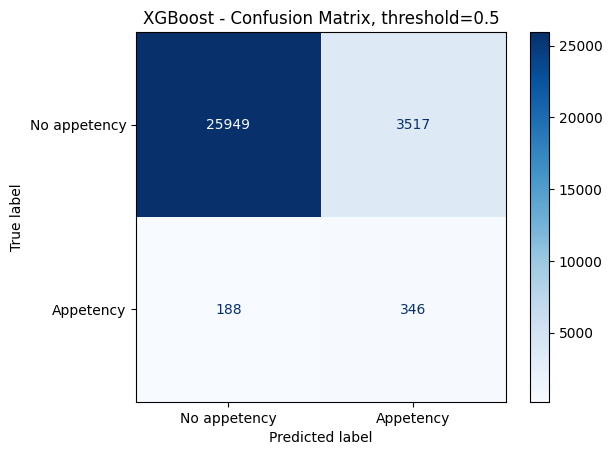

In [30]:
xgb_cv_proba, xgb_cv_pred = evaluate_cv_classifier("XGBoost", final_xgb, X_train, y_train_arr, cv, threshold=0.5)

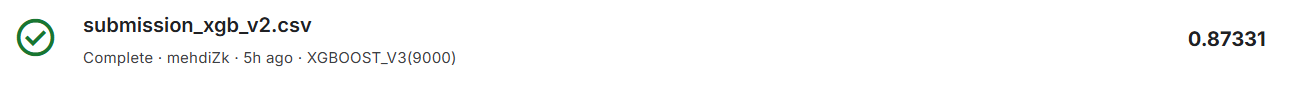

## F) LightGBM

In [32]:
# LIGHTGBM with early stopping
#
# Removed underfitting combos from previous run (lr=0.01, min_child_samples=100,
# bagging). Old best params had num_leaves=15 / lr=0.03 so we anchor around that
# and explore carefully upward.
# bagging disabled (fraction=1.0, freq=0) to isolate the main regularsers first.

lgb_params = {
    'learning_rate':  [0.03, 0.05],
    'num_leaves':        [15, 31],
    'min_child_samples': [20, 50],
    'colsample_bytree':  [0.5],
    'bagging_fraction':  [1.0],
    'bagging_freq':      [0],
    'reg_lambda':        [1, 5],
}

best_lgb_auc  = 0
best_lgb_params  = {}
best_lgb_model  = None
best_lgb_iterations = []   # best_iteration_ per fold for the winning param set

param_combinations_lgb = [dict(zip(lgb_params.keys(), v)) for v in product(*lgb_params.values())]

print(f"LightGBM: {len(param_combinations_lgb)} combinations 5 folds")

for params in param_combinations_lgb:
    fold_aucs  = []
    fold_iterations = []

    for train_idx, val_idx in cv.split(X_train, y_train_arr):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_arr[train_idx],  y_train_arr[val_idx]

        model = lgb.LGBMClassifier(
            **params,
            n_estimators=2000,
            is_unbalance=True,
            metric='auc', 
            random_state=123,
            n_jobs=-1,
            verbosity=-1
        )
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=-1)]
        )
        fold_aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
        fold_iterations.append(model.best_iteration_)

    mean_auc = np.mean(fold_aucs)
    if mean_auc > best_lgb_auc:
        best_lgb_auc        = mean_auc
        best_lgb_params     = params
        best_lgb_model      = model
        best_lgb_iterations = fold_iterations


LightGBM: 16 combinations 5 folds


In [33]:
print(f"Best AUC (CV): {best_lgb_auc:.4f}")
print(f"Best params: {best_lgb_params}")

Best AUC (CV): 0.8571
Best params: {'learning_rate': 0.03, 'num_leaves': 15, 'min_child_samples': 50, 'colsample_bytree': 0.5, 'bagging_fraction': 1.0, 'bagging_freq': 0, 'reg_lambda': 5}


In [34]:
# Floor at 150 prevents the n_estimators=6 failure mode.
# 10% buffer: more training data in full fit → slightly more trees needed.
print(f"Best iterations per fold: {best_lgb_iterations}")
n_est = max(150, int(np.mean(best_lgb_iterations) * 1.1))
print(f"Mean best iteration: {np.mean(best_lgb_iterations):.1f}  →  n_estimators = {n_est}")

final_lgb = lgb.LGBMClassifier(
    **best_lgb_params,
    n_estimators=n_est,
    is_unbalance=True,
    metric='auc', 
    random_state=123,
    n_jobs=-1,
    verbosity=-1
)
final_lgb.fit(X_train, y_train_arr)
lgb_pred = final_lgb.predict_proba(test)[:, 1]


Best iterations per fold: [151, 105, 133, 208, 33]
Mean best iteration: 126.0  →  n_estimators = 150



LightGBM  Classification Report
              precision    recall  f1-score   support

           0     0.9918    0.9234    0.9564     29466
           1     0.1208    0.5805    0.1999       534

    accuracy                         0.9173     30000
   macro avg     0.5563    0.7520    0.5782     30000
weighted avg     0.9763    0.9173    0.9429     30000



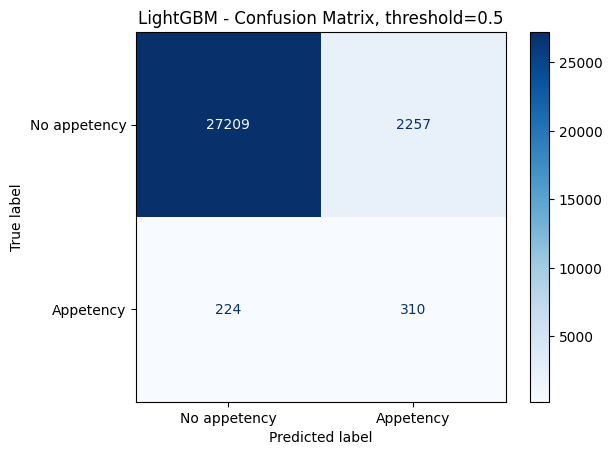

In [35]:
lgb_cv_proba, lgb_cv_pred = evaluate_cv_classifier("LightGBM", final_lgb, X_train, y_train_arr, cv, threshold=0.5)

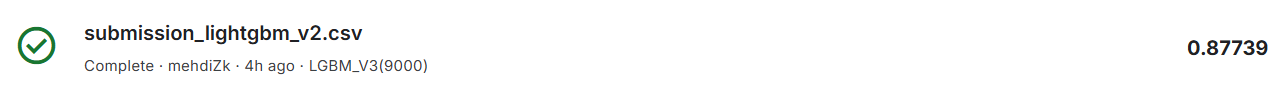

## G) Catboost

In [22]:
# CATBOOST with early stopping
#
# Expanded grid: add learning_rate=0.03 alongside 0.05.
# Track best_iteration_ per fold to fix the final refit (same pattern as LGBM).

cb_params = {
    'learning_rate': [0.03, 0.05],
    'depth':         [4, 6, 8],
    'l2_leaf_reg':   [1, 5, 10],
}

best_cb_auc        = 0
best_cb_params     = {}
best_cb_iterations = []   # best_iteration_ per fold for the winning param set

param_combinations_cb = [dict(zip(cb_params.keys(), v)) for v in product(*cb_params.values())]

print(f"CatBoost: {len(param_combinations_cb)} combinations × 5 folds")

for params in param_combinations_cb:
    fold_aucs       = []
    fold_iterations = []

    for train_idx, val_idx in cv.split(X_train, y_train_arr):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_arr[train_idx],  y_train_arr[val_idx]

        model = CatBoostClassifier(
            **params,
            iterations=2000,
            auto_class_weights='Balanced',
            eval_metric='AUC',
            early_stopping_rounds=50,
            random_seed=123,
            verbose=0
        )
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
        fold_aucs.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
        fold_iterations.append(model.best_iteration_)

    mean_auc = np.mean(fold_aucs)
    if mean_auc > best_cb_auc:
        best_cb_auc        = mean_auc
        best_cb_params     = params
        best_cb_iterations = fold_iterations


CatBoost: 18 combinations × 5 folds


In [23]:
print(f"Best AUC (CV): {best_cb_auc:.4f}")
print(f"Best params: {best_cb_params}")

Best AUC (CV): 0.8633
Best params: {'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5}


In [24]:
print(f"Best iterations per fold: {best_cb_iterations}")
n_est_cb = max(150, int(np.mean(best_cb_iterations) * 1.1))
print(f"Mean best iteration: {np.mean(best_cb_iterations):.1f}  →  iterations = {n_est_cb}")

final_cb = CatBoostClassifier(
    **best_cb_params,
    iterations=n_est_cb,
    auto_class_weights='Balanced',
    random_seed=123,
    verbose=0
)
final_cb.fit(X_train, y_train_arr)
cb_pred = final_cb.predict_proba(test)[:, 1]


Best iterations per fold: [421, 224, 259, 54, 83]
Mean best iteration: 208.2  →  iterations = 229



CatBoost  Classification Report
              precision    recall  f1-score   support

           0     0.9941    0.8153    0.8959     29466
           1     0.0672    0.7341    0.1231       534

    accuracy                         0.8139     30000
   macro avg     0.5307    0.7747    0.5095     30000
weighted avg     0.9776    0.8139    0.8821     30000



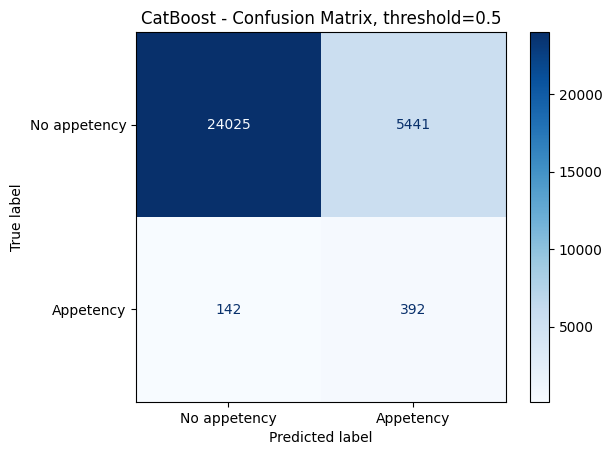

In [25]:
cb_cv_proba, cb_cv_pred = evaluate_cv_classifier("CatBoost", final_cb, X_train, y_train_arr, cv, threshold=0.5)

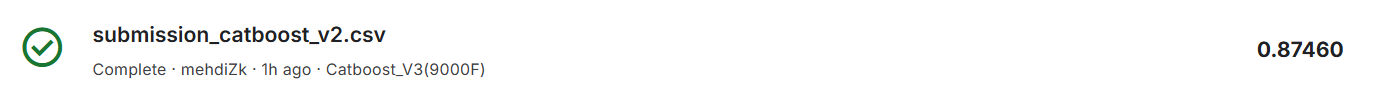

# IV - Model Comparison

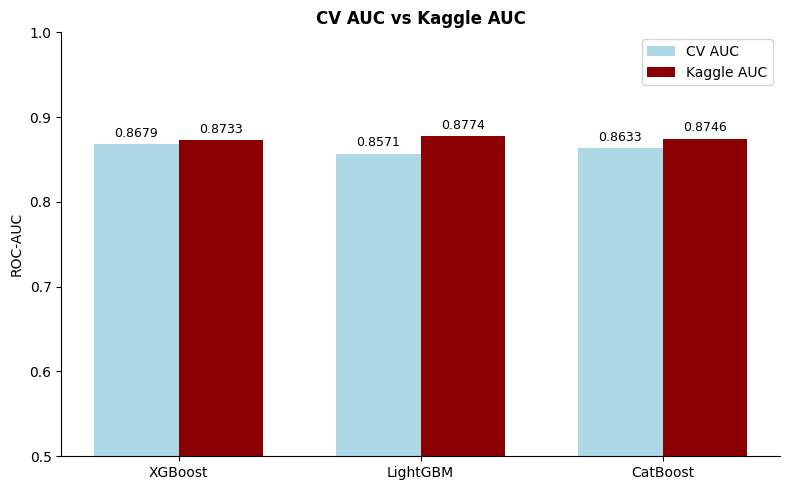

In [37]:
#  CV AUC vs Kaggle AUC

kaggle_scores = {
    "XGBoost":  0.87331,   
    "LightGBM": 0.87739,   
    "CatBoost": 0.87460,   
}

models = ["XGBoost", "LightGBM", "CatBoost"]
cv_aucs = [best_xgb_auc, best_lgb_auc, best_cb_auc]
kag_aucs = [kaggle_scores[m] if kaggle_scores[m] is not None else float("nan") for m in models]

x= np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_cv  = ax.bar(x - width / 2, cv_aucs,  width, label="CV AUC", color="lightblue")
bars_kag= ax.bar(x + width / 2, kag_aucs, width, label="Kaggle AUC", color="darkred")

ax.set_ylabel("ROC-AUC")
ax.set_title("CV AUC vs Kaggle AUC", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 1)
ax.legend()

# adding the values on top of the bars
for bar in bars_cv:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars_kag:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

plt.show()

# V - Exporting

In [ ]:
# Export submissions: XGBoost v2, LightGBM v2, CatBoost v2

submission_xgb = pd.DataFrame({"ID": test.index, "Target_appetency": xgb_pred})
submission_lgb = pd.DataFrame({"ID": test.index, "Target_appetency": lgb_pred})
submission_cb  = pd.DataFrame({"ID": test.index, "Target_appetency": cb_pred})

submission_xgb.to_csv("output/submission_xgb_v2.csv", index=False)
submission_lgb.to_csv("output/submission_lightgbm_v2.csv",  index=False)
submission_cb.to_csv( "output/submission_catboost_v2.csv",  index=False)

display(submission_xgb.head())
display(submission_lgb.head())
display(submission_cb.head())


,ID,Target_appetency
0,877149,0.564422
1,109603,0.187028
2,560424,0.056668
3,386592,0.186556
4,857379,0.441328


,ID,Target_appetency
0,877149,0.401352
1,109603,0.067648
2,560424,0.016442
3,386592,0.072412
4,857379,0.268926


,ID,Target_appetency
0,877149,0.541701
1,109603,0.244201
2,560424,0.229782
3,386592,0.302282
4,857379,0.494357


# End of the boosting models notebook